INIT

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import difflib
from google.colab import drive
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

drive.mount('/content/drive')

# Configuración
CORPUS_PATH = '/content/drive/MyDrive/TFM_Corpus'
SENSOR_ORDER = ['chest', 'waist', 'wrist_L', 'wrist_R']
VALID_CLASSES = ['Drive', 'Serve', 'BackhandRH', 'BackhandTwoH', 'Lob', 'Waiting']
WINDOW_SIZE = 200
FEATURES_PER_SENSOR = 3
N_CHANNELS = len(SENSOR_ORDER) * FEATURES_PER_SENSOR

def validate_and_correct_label(label, file_info):
    label_str = str(label).strip()
    if label_str in VALID_CLASSES: return label_str
    match = difflib.get_close_matches(label_str, VALID_CLASSES, n=1, cutoff=0.6)
    if match:
        print(f"[{file_info}] Corregido: '{label_str}' -> '{match[0]}'")
        return match[0]
    return None

def load_tfm_dataset(base_paths):
    X_list, y_list, subject_ids = [], [], []
    for path in base_paths:
        print(f"Cargando desde: {path}")
        subjects = sorted([d for d in os.listdir(path) if d.startswith('P')])
        for sub_idx, subject in enumerate(subjects):
            sub_path = os.path.join(path, subject)
            sessions = sorted([d for d in os.listdir(sub_path) if os.path.isdir(os.path.join(sub_path, d))])
            for session in sessions:
                sess_path = os.path.join(sub_path, session)
                session_sensors, session_labels, valid_session = [], None, True
                for sensor in SENSOR_ORDER:
                    file_path = os.path.join(sess_path, f'sensor_{sensor}.csv')
                    if not os.path.exists(file_path): valid_session = False; break

                    df = pd.read_csv(file_path, header=None)
                    if df.shape[1] != 602: valid_session = False; break
                    df = df.dropna()

                    labels_corrected, rows_to_keep = [], []
                    for idx, row in df.iterrows():
                        corrected = validate_and_correct_label(row[601], f"{subject}/{session}")
                        if corrected: labels_corrected.append(corrected); rows_to_keep.append(idx)

                    df = df.loc[rows_to_keep]
                    data = df.iloc[:, 1:601].values.reshape(-1, WINDOW_SIZE, FEATURES_PER_SENSOR)
                    session_sensors.append(data)
                    if session_labels is None: session_labels = np.array(labels_corrected)

                if valid_session and len(session_sensors) == len(SENSOR_ORDER):
                    min_w = min(s.shape[0] for s in session_sensors)
                    X_list.append(np.concatenate([s[:min_w] for s in session_sensors], axis=2))
                    y_list.append(session_labels[:min_w])
                    subject_ids.append(np.full(min_w, sub_idx))
    return np.concatenate(X_list), np.concatenate(y_list), np.concatenate(subject_ids)

Mounted at /content/drive


ARQUITECTURA DE RED

In [2]:
def create_model_improved():
    model = Sequential([
        Input(shape=(WINDOW_SIZE, N_CHANNELS)),

        # Envoltura Bidireccional para extraer dependencias pasadas y futuras de la señal
        Bidirectional(LSTM(64, return_sequences=True)),
        BatchNormalization(),
        Dropout(0.3),

        Bidirectional(LSTM(32)),
        Dropout(0.3),

        Dense(16, activation='relu'),
        Dense(len(VALID_CLASSES), activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def run_experiment(X, y, subjects, title):
    print(f"\n{'='*20} EXPERIMENTO: {title} {'='*20}")
    le = LabelEncoder().fit(VALID_CLASSES)
    y_enc = le.transform(y)
    unique_subs = np.unique(subjects)
    all_y_true, all_y_pred, fold_accs = [], [], []

    # Parada temprana obligando a un mínimo de épocas.
    early_stop = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, start_from_epoch=15)

    # Reducción de la tasa de aprendizaje si no hay mejora en 5 épocas
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001, verbose=0)

    for test_sub in unique_subs:
        X_train, y_train = X[subjects != test_sub], y_enc[subjects != test_sub]
        X_test, y_test = X[subjects == test_sub], y_enc[subjects == test_sub]

        model = create_model_improved()
        history = model.fit(X_train, y_train, epochs=100, batch_size=64, verbose=0,
                            validation_split=0.1, callbacks=[early_stop, reduce_lr])

        preds = np.argmax(model.predict(X_test, verbose=0), axis=1)
        acc = accuracy_score(y_test, preds)
        fold_accs.append(acc)

        epocas_reales = len(history.history['loss'])
        print(f"Fold P{test_sub+1}: {acc:.4f} (Épocas ejecutadas: {epocas_reales}/100)")

        all_y_true.extend(y_test); all_y_pred.extend(preds)

    print(f"\n[RESULTADO GLOBAL] Media: {np.mean(fold_accs):.4f}")
    cm = confusion_matrix(all_y_true, all_y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Matriz de Confusión: {title}')
    plt.show()
    print(classification_report(all_y_true, all_y_pred, target_names=le.classes_))

EXPERIMENTO 1: CUSTOM

Cargando desde: /content/drive/MyDrive/TFM_Corpus/Custom

==================== EXPERIMENTO: SOLO CUSTOM ====================
Fold P1: 0.9500 (Épocas ejecutadas: 28/100)
Fold P2: 0.6819 (Épocas ejecutadas: 27/100)
Fold P3: 0.6097 (Épocas ejecutadas: 30/100)
Fold P4: 0.8486 (Épocas ejecutadas: 27/100)
Fold P5: 0.5139 (Épocas ejecutadas: 27/100)
Fold P6: 0.8389 (Épocas ejecutadas: 27/100)
Fold P7: 0.9153 (Épocas ejecutadas: 27/100)
Fold P8: 0.7875 (Épocas ejecutadas: 27/100)
Fold P9: 0.7042 (Épocas ejecutadas: 27/100)
Fold P10: 0.8764 (Épocas ejecutadas: 27/100)
Fold P11: 0.6319 (Épocas ejecutadas: 37/100)
Fold P12: 0.6444 (Épocas ejecutadas: 27/100)

[RESULTADO GLOBAL] Media: 0.7502


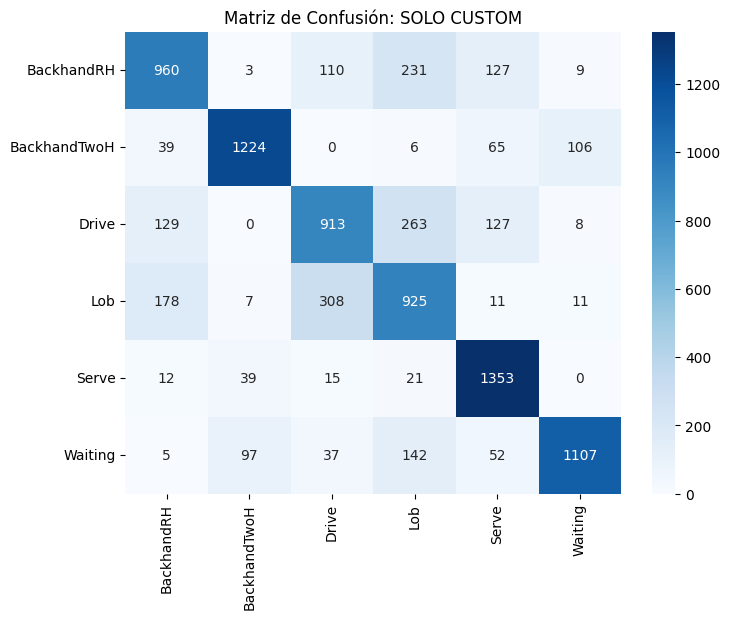

              precision    recall  f1-score   support

  BackhandRH       0.73      0.67      0.69      1440
BackhandTwoH       0.89      0.85      0.87      1440
       Drive       0.66      0.63      0.65      1440
         Lob       0.58      0.64      0.61      1440
       Serve       0.78      0.94      0.85      1440
     Waiting       0.89      0.77      0.83      1440

    accuracy                           0.75      8640
   macro avg       0.76      0.75      0.75      8640
weighted avg       0.76      0.75      0.75      8640



In [ ]:
path_custom = [os.path.join(CORPUS_PATH, 'Custom')]
X_c, y_c, sub_c = load_tfm_dataset(path_custom)
run_experiment(X_c, y_c, sub_c, "SOLO CUSTOM")

EXPERIMENTO 2: COMMERCIAL

Cargando desde: /content/drive/MyDrive/TFM_Corpus/Commercial

==================== EXPERIMENTO: SOLO COMMERCIAL ====================
Fold P1: 0.9500 (Épocas ejecutadas: 28/100)
Fold P2: 0.6069 (Épocas ejecutadas: 29/100)
Fold P3: 0.8861 (Épocas ejecutadas: 33/100)
Fold P4: 0.7556 (Épocas ejecutadas: 27/100)
Fold P5: 0.4667 (Épocas ejecutadas: 27/100)
Fold P6: 0.7278 (Épocas ejecutadas: 27/100)
Fold P7: 0.7514 (Épocas ejecutadas: 27/100)
Fold P8: 0.8556 (Épocas ejecutadas: 27/100)
Fold P9: 0.7722 (Épocas ejecutadas: 27/100)
Fold P10: 0.7889 (Épocas ejecutadas: 27/100)
Fold P11: 0.4583 (Épocas ejecutadas: 27/100)
Fold P12: 0.8583 (Épocas ejecutadas: 27/100)

[RESULTADO GLOBAL] Media: 0.7398


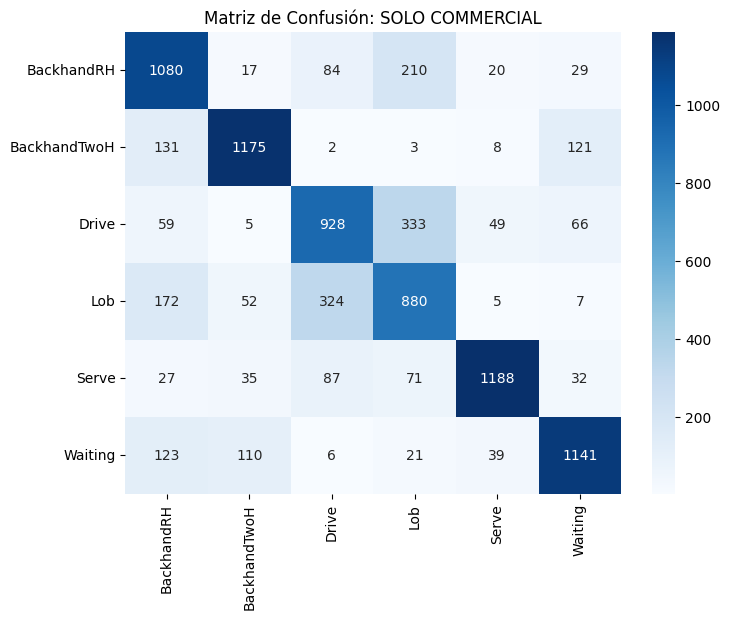

              precision    recall  f1-score   support

  BackhandRH       0.68      0.75      0.71      1440
BackhandTwoH       0.84      0.82      0.83      1440
       Drive       0.65      0.64      0.65      1440
         Lob       0.58      0.61      0.59      1440
       Serve       0.91      0.82      0.86      1440
     Waiting       0.82      0.79      0.80      1440

    accuracy                           0.74      8640
   macro avg       0.75      0.74      0.74      8640
weighted avg       0.75      0.74      0.74      8640



In [ ]:
path_comm = [os.path.join(CORPUS_PATH, 'Commercial')]
X_m, y_m, sub_m = load_tfm_dataset(path_comm)
run_experiment(X_m, y_m, sub_m, "SOLO COMMERCIAL")

EXPERIMENTO 3: TOTAL

Cargando desde: /content/drive/MyDrive/TFM_Corpus/Custom
Cargando desde: /content/drive/MyDrive/TFM_Corpus/Commercial

==================== EXPERIMENTO: TOTAL (COMBINADO) ====================
Fold P1: 0.9882 (Épocas ejecutadas: 36/100)
Fold P2: 0.6715 (Épocas ejecutadas: 30/100)
Fold P3: 0.8451 (Épocas ejecutadas: 27/100)
Fold P4: 0.9028 (Épocas ejecutadas: 27/100)
Fold P5: 0.5632 (Épocas ejecutadas: 27/100)
Fold P6: 0.8243 (Épocas ejecutadas: 27/100)
Fold P7: 0.9132 (Épocas ejecutadas: 58/100)
Fold P8: 0.9285 (Épocas ejecutadas: 27/100)
Fold P9: 0.7951 (Épocas ejecutadas: 27/100)
Fold P10: 0.8382 (Épocas ejecutadas: 27/100)
Fold P11: 0.7778 (Épocas ejecutadas: 27/100)
Fold P12: 0.7562 (Épocas ejecutadas: 27/100)

[RESULTADO GLOBAL] Media: 0.8170


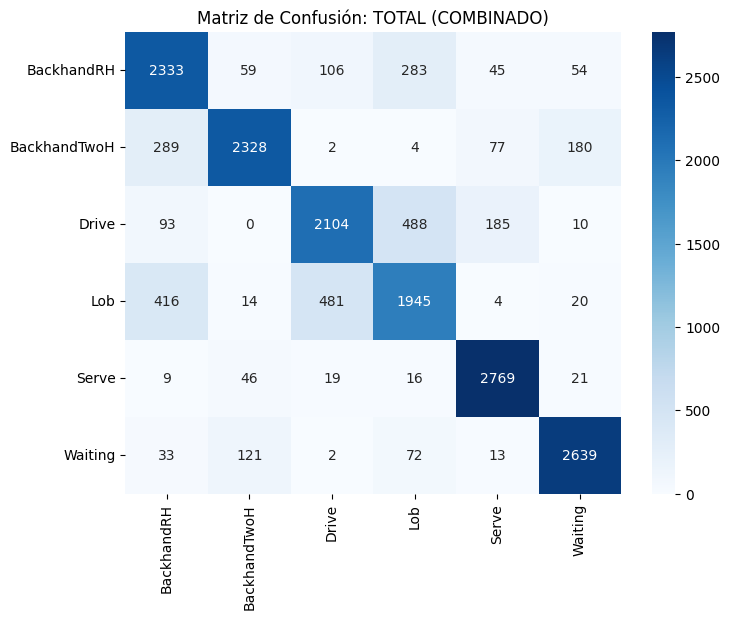

              precision    recall  f1-score   support

  BackhandRH       0.74      0.81      0.77      2880
BackhandTwoH       0.91      0.81      0.85      2880
       Drive       0.78      0.73      0.75      2880
         Lob       0.69      0.68      0.68      2880
       Serve       0.90      0.96      0.93      2880
     Waiting       0.90      0.92      0.91      2880

    accuracy                           0.82     17280
   macro avg       0.82      0.82      0.82     17280
weighted avg       0.82      0.82      0.82     17280



In [ ]:
paths_all = [os.path.join(CORPUS_PATH, 'Custom'), os.path.join(CORPUS_PATH, 'Commercial')]
X_t, y_t, sub_t = load_tfm_dataset(paths_all)
run_experiment(X_t, y_t, sub_t, "TOTAL (COMBINADO)")

ENTRENAMIENTO FINAL Y EXPORTACIÓN

In [ ]:
print("Entrenando modelo final de producción con dataset TOTAL...")
le_final = LabelEncoder().fit(VALID_CLASSES)
y_enc_t = le_final.transform(y_t)

model_final = create_model_improved()

# EarlyStopping con min_delta
early_stop_final = EarlyStopping(
    monitor='loss',
    min_delta=0.005,
    patience=5,
    restore_best_weights=True,
    start_from_epoch=15
)

reduce_lr_final = ReduceLROnPlateau(
    monitor='loss',
    factor=0.5,
    patience=3,
    min_lr=0.0001,
    verbose=1
)

# Ejecución del entrenamiento
model_final.fit(
    X_t,
    y_enc_t,
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=[early_stop_final, reduce_lr_final]
)

# Exportación de archivos
model_filename = "modelo_tenis_v2_final"
with open(f"{model_filename}.json", "w") as f:
    f.write(model_final.to_json())
model_final.save_weights(f"{model_filename}.weights.h5")

print(f"\n--- EXPORTACIÓN COMPLETADA ---")

Entrenando modelo final de producción con dataset TOTAL...
Epoch 1/100
270/270 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.6463 - loss: 0.9113 - learning_rate: 0.0010
Epoch 2/100
270/270 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.8806 - loss: 0.3374 - learning_rate: 0.0010
Epoch 3/100
270/270 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.9378 - loss: 0.1811 - learning_rate: 0.0010
Epoch 4/100
270/270 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9416 - loss: 0.1638 - learning_rate: 0.0010
Epoch 5/100
270/270 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.9754 - loss: 0.0730 - learning_rate: 0.0010
Epoch 6/100
270/270 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.9748 - loss: 0.0732 - learning_rate: 0.0010
Epoch 7/100
270/270 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.9814 - loss: 0.0612 - learning_rate: 0.0010
Epoch 8/100
270/270 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.9857 - loss: 0.0455 - learning_rate: 0.0010
Epoch 9/100
270/270 ━━━━━━━━━━━━━━━━━━━━ 8s

EXPERIMENTO 4: ABLACIÓN

In [ ]:
import itertools
import numpy as np
import os

def run_fast_ablation_study(X, y, subjects):
    print(f"\n{'='*20} ESTUDIO DE ABLACIÓN (ZERO-MASKING) {'='*20}")
    print("Entrenando 1 vez por pliegue. Evaluando 15 combinaciones...\n")

    le = LabelEncoder().fit(VALID_CLASSES)
    y_enc = le.transform(y)
    unique_subs = np.unique(subjects)

    # Mapa de qué canales pertenecen a qué sensor
    sensor_indices = {
        'chest': [0, 1, 2],
        'waist': [3, 4, 5],
        'wrist_L': [6, 7, 8],
        'wrist_R': [9, 10, 11]
    }

    # Generar las 15 combinaciones posibles de los 4 sensores (tamaños 1, 2, 3 y 4)
    all_combinations = []
    for r in range(1, len(SENSOR_ORDER) + 1):
        all_combinations.extend(list(itertools.combinations(SENSOR_ORDER, r)))

    # Diccionario para acumular los aciertos de cada combinación
    ablation_results = {comb: [] for comb in all_combinations}

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        start_from_epoch=15  # Prevenir underfitting
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=0.0001,
        verbose=0
    )

    for test_sub in unique_subs:
        print(f"--- FOLD P{test_sub+1} ---")

        # Split estándar
        X_train, y_train = X[subjects != test_sub], y_enc[subjects != test_sub]
        X_test, y_test = X[subjects == test_sub], y_enc[subjects == test_sub]

        # Entrenar el modelo una vez con todos los sensores
        model = create_model_improved()
        # Capturamos el historial del entrenamiento en la variable 'history'
        history = model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=64,
            verbose=0,
            validation_split=0.1,
            callbacks=[early_stop, reduce_lr]
        )

        # Extraemos el número de épocas reales ejecutadas
        epocas_ejecutadas = len(history.history['loss'])
        print(f"    Modelo maestro convergido en {epocas_ejecutadas} épocas.")

        # Testear todas las combinaciones mediante enmascaramiento (Zero-Masking)
        print("    Resultados de ablación parciales:")
        for comb in all_combinations:
            # Hacemos una copia profunda de los datos de test
            X_test_masked = np.copy(X_test)

            # Identificamos qué sensores NO están en esta combinación y los apagamos a 0
            sensors_to_zero = [s for s in SENSOR_ORDER if s not in comb]
            for s in sensors_to_zero:
                idx = sensor_indices[s]
                # Ponemos a 0 todo el eje temporal de esos canales específicos
                X_test_masked[:, :, idx] = 0.0

            # Predecimos con la señal enmascarada
            preds = np.argmax(model.predict(X_test_masked, verbose=0), axis=1)
            acc = accuracy_score(y_test, preds)

            # Guardamos el resultado
            ablation_results[comb].append(acc)

            sensores_activos = " + ".join(comb)
            # Añadimos una marca visual para identificar rápidamente el modelo completo
            marker = "⭐" if len(comb) == 4 else "  "
            print(f"      {marker} [{acc:.4f}] -> {sensores_activos}")

        print("-" * 40)

    # Reporte final
    print("\n" + "="*50)
    print("RANKING DEL ESTUDIO DE ABLACIÓN (Precisión Media)")
    print("="*50)

    # Calculamos la media de las 12 iteraciones para cada combinación
    ranking = []
    for comb, accs in ablation_results.items():
        ranking.append((comb, np.mean(accs)))

    # Ordenamos de mayor a menor precisión
    ranking.sort(key=lambda x: x[1], reverse=True)

    # Imprimimos los resultados
    for i, (comb, acc) in enumerate(ranking):
        sensores = " + ".join(comb)
        # Resaltamos el modelo completo
        marker = "⭐" if len(comb) == 4 else "  "
        print(f"{i+1:02d}. {marker} [{acc:.4f}] -> {sensores}")

# Estudio con la base de datos total
print("Cargando datos totales para la ablación...")
paths_all = [os.path.join(CORPUS_PATH, 'Custom'), os.path.join(CORPUS_PATH, 'Commercial')]
X_t, y_t, sub_t = load_tfm_dataset(paths_all)

# Ejecutamos la función de ablación
run_fast_ablation_study(X_t, y_t, sub_t)

Cargando datos totales para la ablación...
Cargando desde: /content/drive/MyDrive/TFM_Corpus/Custom
Cargando desde: /content/drive/MyDrive/TFM_Corpus/Commercial

==================== ESTUDIO DE ABLACIÓN (ZERO-MASKING) ====================
Entrenando 1 vez por pliegue. Evaluando 15 combinaciones...

--- FOLD P1 ---
    Modelo maestro convergido en 29 épocas.
    Resultados de ablación parciales:
         [0.1972] -> chest
         [0.1639] -> waist
         [0.3569] -> wrist_L
         [0.4660] -> wrist_R
         [0.2354] -> chest + waist
         [0.3431] -> chest + wrist_L
         [0.6861] -> chest + wrist_R
         [0.4229] -> waist + wrist_L
         [0.7410] -> waist + wrist_R
         [0.9181] -> wrist_L + wrist_R
         [0.4014] -> chest + waist + wrist_L
         [0.7931] -> chest + waist + wrist_R
         [0.9222] -> chest + wrist_L + wrist_R
         [0.9632] -> waist + wrist_L + wrist_R
      ⭐ [0.9764] -> chest + waist + wrist_L + wrist_R
------------------------------